In [1]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from models import EEGNet

In [4]:
device = torch.device(
    "cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [ ]:
# 1. Load the file
data = np.load("data/dataset_230348.npz")
X_raw = data['X']  # Shape: (Trials, TimeSteps, Channels)
y_raw = data['y']  # Shape: (Trials,)

# 2. Convert to PyTorch Tensors
X_tensor = torch.tensor(X_raw, dtype=torch.float32)

# CNNs usually expect the channel dimension before the time dimension!
# So we swap 'Time' and 'Channels': resulting in (Batch, Channels, Time)


# 3. Encode your string labels into numerical classes for PyTorch
unique_labels = np.unique(y_raw)
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
y_mapped = np.array([label_to_index[label] for label in y_raw])
y_tensor = torch.tensor(y_mapped, dtype=torch.long)


X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.33, random_state=42)

# 4. Ready for training!
dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [8]:
next(iter(dataloader))[0].shape

torch.Size([4, 1, 8, 1000])

In [74]:
model = EEGNet(n_classes=6, electrode_channels=5,
               sample_length=2000).to(device=device)
criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters())

In [75]:
num_epochs = 100

for epoch in range(num_epochs):
    running_loss = 0.0
    outputs: torch.Tensor = torch.tensor([])
    labels: torch.Tensor = torch.tensor([])
    # 4. Inner loop to iterate over DataLoader batches
    for inputs, labels in dataloader:
        inputs = inputs.unsqueeze(1).to(device)
        labels = labels.to(device)

        # 5. Clear previous gradients
        optim.zero_grad()

        # 6. Forward pass through network
        outputs = model(inputs)

        # 7. Compute loss metrics
        loss = criterion(outputs, labels)

        # 8. Backward pass (calculate gradients)
        loss.backward()

        # 9. Update network weights
        optim.step()

        # 10. Track ongoing performance
        running_loss += loss.item()

    if epoch % 10 == 0:
        model.eval()
        y_pred = model.forward(X_test.unsqueeze(1).to(device))

        acc = accuracy_score(y_pred.detach().cpu().numpy().argmax(axis=1),
                             y_test.detach().cpu().numpy())
        print(f"Acc: {acc}")

Acc: 0.35
Acc: 0.5
Acc: 0.6
Acc: 0.6
Acc: 0.6
Acc: 0.55
Acc: 0.575
Acc: 0.55
Acc: 0.575
Acc: 0.575


In [ ]:
model.eval()
y_pred = model.forward(X_test.unsqueeze(1).to(device))

confusion_matrix(y_pred.detach().cpu().numpy().argmax(axis=1),
                 y_test.detach().cpu().numpy())

array([[3, 0, 0, 0, 0, 0],
       [0, 3, 0, 0, 0, 0],
       [0, 0, 4, 0, 0, 2],
       [0, 0, 0, 3, 0, 0],
       [0, 0, 0, 0, 3, 0],
       [0, 0, 0, 0, 0, 2]])

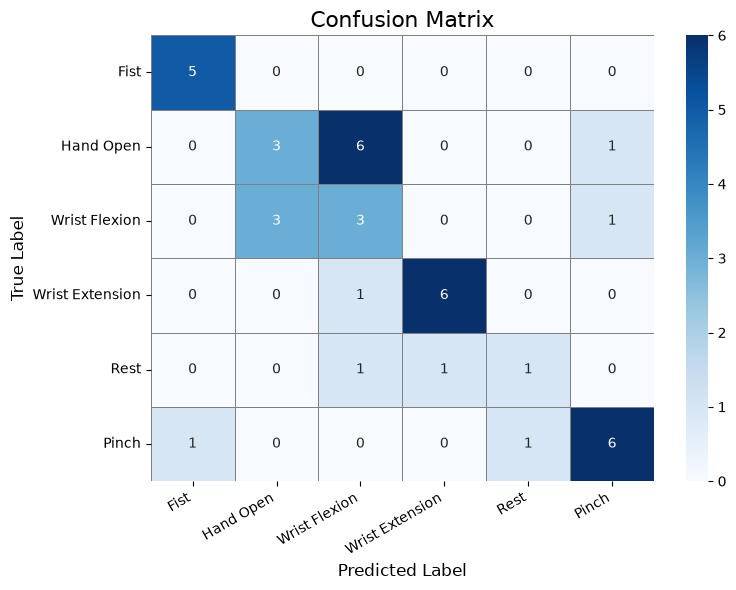

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ACTIONS = [
    "Fist",
    "Hand Open",
    "Wrist Flexion",
    "Wrist Extension",
    "Rest",
    "Pinch"
]

# Predictions
model.eval()
with torch.no_grad():
    y_pred = model(X_test.unsqueeze(1).to(device))

y_true = y_test.cpu().numpy()
y_pred = y_pred.cpu().numpy().argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ACTIONS,
    yticklabels=ACTIONS,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
torch.save(model, "55.pth")

In [72]:
torch.load("80.pth", weights_only=False)

EEGNet(
  (block1_conv1): Conv2d(1, 8, kernel_size=(1, 32), stride=(1, 1), padding=same, bias=False)
  (block1_bn1): BatchNorm2d(8, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block1_conv2): Conv2d(8, 16, kernel_size=(5, 1), stride=(1, 1), groups=8, bias=False)
  (block1_bn2): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block1_elu): ELU(alpha=1.0)
  (block1_pool): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (block1_dropout): Dropout(p=0.5, inplace=False)
  (block2_conv1): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
  (block2_conv2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (block2_bn): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block2_elu): ELU(alpha=1.0)
  (block2_pool): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (block2_dropout): Dropout(p=0.5, inplace=F